In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [13]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [110]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [93]:
df = pd.read_csv("./data/fashionmnist/versions/4/fashion-mnist_test.csv")
df.groupby("label")["label"].sum()

label
0       0
1    1000
2    2000
3    3000
4    4000
5    5000
6    6000
7    7000
8    8000
9    9000
Name: label, dtype: int64

In [114]:
df.shape

(10000, 785)

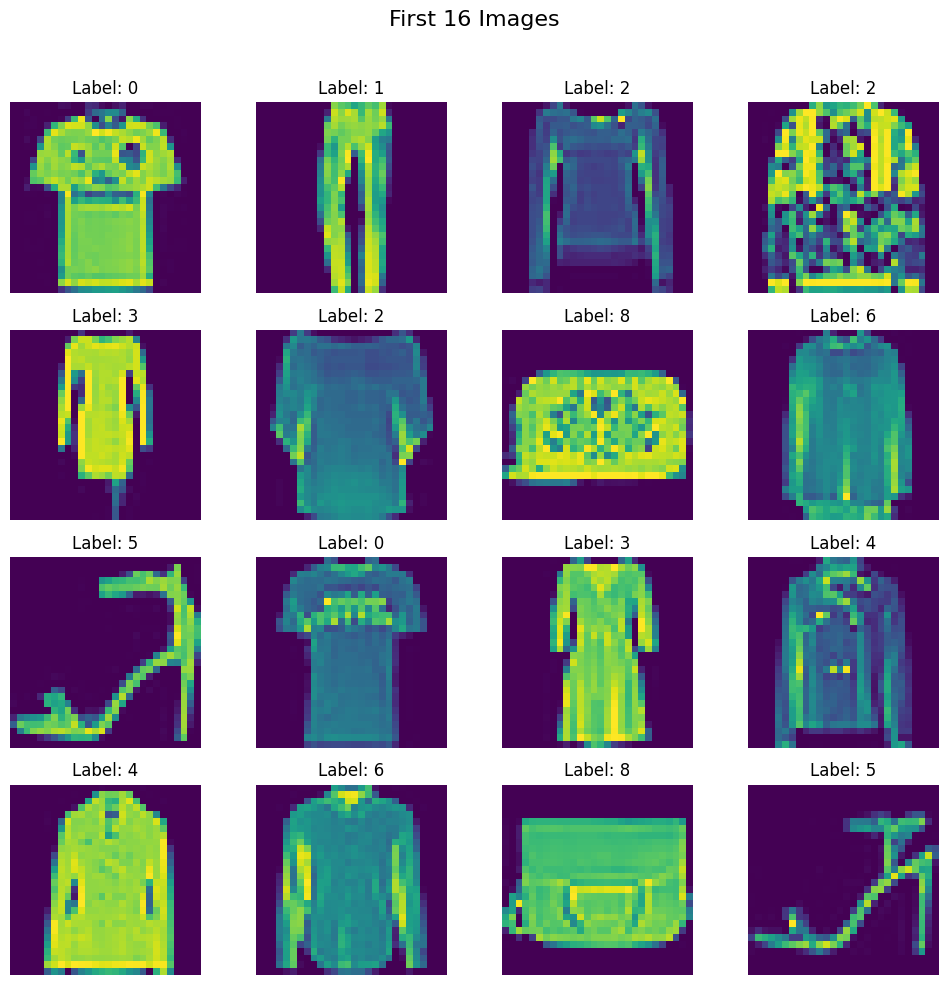

In [18]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [24]:
# train teset split 
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [96]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 1, 3, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(10000, 784))

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
# our pixel values from 0 to 255 to make a peoper model we scale them 0 - 1 
#  so divde them by 255
X_train = X_train/255.0
X_test = X_test/255.0

In [27]:
X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.45098039, 0.1372549 ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(8000, 784))

In [49]:
# create teh CustomDataset Class
class CustomDataset(Dataset):
    
    def __init__(self,features,labels):
        self.features = torch.tensor(features,dtype=torch.float32)
        self.labels = torch.tensor(labels,dtype=torch.float64)
    
    def __len__(self):
        return len(self.features)
    def __getitem__(self,index):
        return self.features[index],self.labels[index]

In [50]:
# create train dataset object
train_dataset = CustomDataset(X_train,y_train)

In [52]:
test_dataset = CustomDataset(X_test,y_test)

In [53]:
# create train snd test loader
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=True)


In [86]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [119]:
# define the NN
class MyNN(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64,10)
        )    
    def forward(self,x):
        return self.model(x)


In [57]:
#  set lr and epochs
epochs = 100
learning_rate = 0.1

In [58]:
X_train.shape

(8000, 784)

In [120]:
# instentiate the model
model = MyNN(X_train.shape[1])
model.to(device)

# loss funston
criterion = nn.CrossEntropyLoss()

# optimmizer 
optimizer = optim.SGD(model.parameters(),lr = learning_rate,weight_decay=1e-4)

In [112]:
for batch_features,batch_lables in train_loader:
    print(batch_lables)

tensor([2., 6., 9., 4., 5., 5., 1., 4., 6., 4., 1., 7., 9., 1., 0., 9., 3., 2.,
        5., 9., 9., 7., 9., 8., 6., 9., 7., 5., 7., 5., 8., 1.],
       dtype=torch.float64)
tensor([1., 0., 3., 4., 6., 9., 8., 4., 0., 4., 5., 6., 8., 4., 9., 2., 4., 6.,
        4., 7., 3., 1., 2., 4., 1., 2., 7., 7., 9., 8., 3., 1.],
       dtype=torch.float64)
tensor([2., 2., 0., 4., 8., 6., 8., 7., 2., 8., 8., 3., 5., 4., 6., 3., 8., 4.,
        8., 5., 0., 3., 4., 4., 4., 4., 1., 9., 8., 9., 0., 3.],
       dtype=torch.float64)
tensor([3., 7., 7., 7., 8., 9., 7., 1., 3., 8., 2., 3., 8., 3., 4., 7., 1., 8.,
        0., 7., 7., 4., 3., 7., 2., 8., 0., 5., 0., 7., 1., 5.],
       dtype=torch.float64)
tensor([3., 7., 1., 3., 4., 0., 3., 7., 3., 5., 5., 8., 3., 0., 2., 3., 6., 3.,
        0., 9., 5., 7., 3., 1., 3., 5., 5., 6., 5., 9., 9., 1.],
       dtype=torch.float64)
tensor([2., 8., 0., 7., 0., 8., 4., 6., 6., 2., 7., 1., 0., 7., 6., 0., 8., 6.,
        8., 7., 4., 8., 4., 9., 2., 0., 8., 3., 0., 8.,

In [121]:
# traininig loop
for epoch in range(epochs):
    total_epoch_loss = 0;
    for batch_features,batch_labels in train_loader:
        # forward pass 
        preds = model(batch_features)

        # calculate teh loss
        batch_labels = batch_labels.long()
        loss = criterion(preds, batch_labels)   

        # back propogation
        optimizer.zero_grad()
        loss.backward()

        # update grads
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch {epoch + 1 } Loss: {avg_loss}")

Epoch 1 Loss: 0.8639746714830399
Epoch 2 Loss: 0.6297511458396912
Epoch 3 Loss: 0.5459700131416321
Epoch 4 Loss: 0.5377495455741882
Epoch 5 Loss: 0.4911013053059578
Epoch 6 Loss: 0.4702617723941803
Epoch 7 Loss: 0.4461364400982857
Epoch 8 Loss: 0.4222431910634041
Epoch 9 Loss: 0.4161887063384056
Epoch 10 Loss: 0.40410154494643213
Epoch 11 Loss: 0.41359188863635066
Epoch 12 Loss: 0.38358576607704165
Epoch 13 Loss: 0.3766503539383411
Epoch 14 Loss: 0.3691612359881401
Epoch 15 Loss: 0.36523466658592224
Epoch 16 Loss: 0.34132546573877337
Epoch 17 Loss: 0.34331801438331605
Epoch 18 Loss: 0.33423045963048936
Epoch 19 Loss: 0.33534625923633576
Epoch 20 Loss: 0.3226443467587233
Epoch 21 Loss: 0.3213545102477074
Epoch 22 Loss: 0.306574465572834
Epoch 23 Loss: 0.30036955869197846
Epoch 24 Loss: 0.2904574179947376
Epoch 25 Loss: 0.2893262684941292
Epoch 26 Loss: 0.29659936621785166
Epoch 27 Loss: 0.2798126802742481
Epoch 28 Loss: 0.28098576121032237
Epoch 29 Loss: 0.2831322662010789
Epoch 30 Loss

In [122]:
#  eavaluation to eval mdoe
model.eval()


MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [125]:
#  evaluaton code
total = 0
correct = 0

with torch.no_grad():
    for batch_features,batch_labels in test_loader:
        # print(batch_labels.shape[0])
        # returns the batch with probabillity for every class
        #  label we have and the one has highest probaility is 
        # our output for prediction
        outputs = model(batch_features)
        _,predicted = torch.max(outputs,1)

        # "to calauate how many inputs are there we batchs
        #  with 32 size soa adding the sahpe of rows == 32  
        # every iteration gives us the total number of inputs"
        total = total + batch_labels.shape[0] 
        # print(predicted == batch_labels)
        correct = correct + (predicted == batch_labels).sum().item()
# print(total,correct)
print(correct/total)

0.855


cpu
